#DBSCAN

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

#K-distance graph (choose best eps)

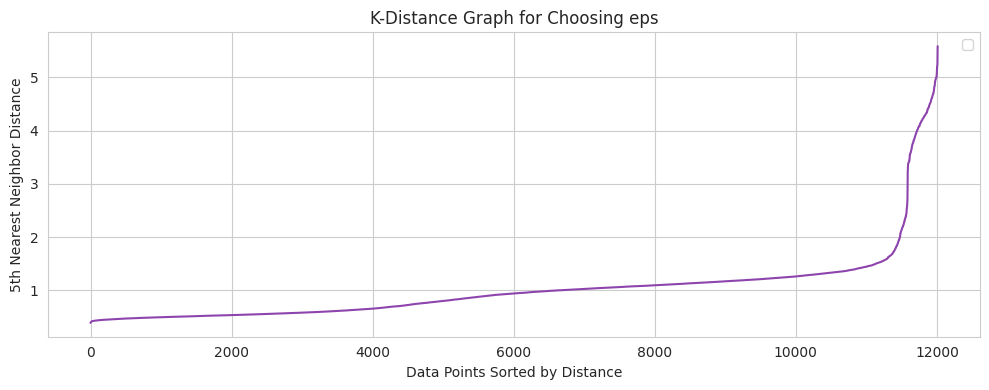

In [18]:
k = 25
neighbors = NearestNeighbors(n_neighbors= k).fit(scaled_array)
distances, _ = neighbors.kneighbors(scaled_array)
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 4))
plt.plot(k_distances, color='#8e44ad', linewidth=1.5)
plt.xlabel("Data Points Sorted by Distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Graph for Choosing eps")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

eps tuning (comparison) & Silhouette based EPS selection

 eps  n_clusters  noise_%  score
1.00           5    24.00   0.47
1.10           5    13.10   0.53
1.20           6     7.70   0.56
1.30           7     5.60   0.57
1.40           7     5.00   0.57
1.50           7     4.80   0.57
1.60           7     4.60   0.57
1.70           7     4.40   0.57
1.80           8     4.00   0.52
1.90           7     3.90   0.59
2.00           7     3.70   0.59
2.10           7     3.60   0.59
2.20           7     3.60   0.59
2.30           7     3.60   0.59
2.40           6     3.50   0.65
2.50           6     3.50   0.65
2.60           6     3.50   0.65
2.70           6     3.50   0.65
2.80           6     3.50   0.65
2.90           6     3.50   0.65
3.00           6     3.50   0.65
3.10           3     3.50   0.19
3.20           4     3.30   0.16
3.30           4     3.00   0.16
3.40           4     2.70   0.16

Best eps: 2.4 (score: 0.6487, clusters: 6)


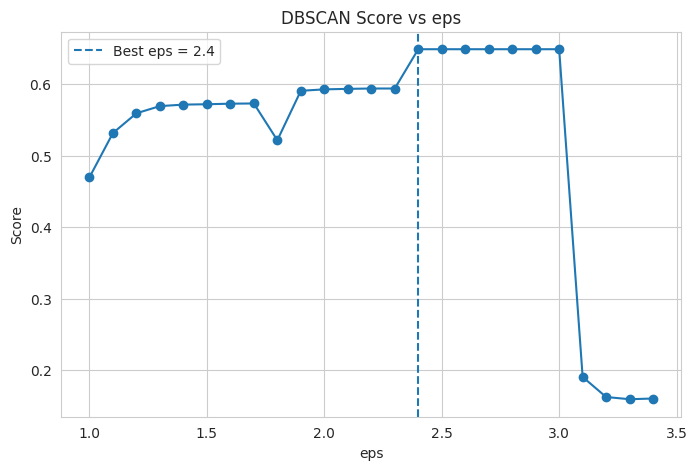

In [19]:
eps_range = np.arange(1.0, 3.5, 0.1)
results_db = []

for eps in eps_range:
    db = DBSCAN(
        eps=eps,
        min_samples=25
    )
    labels = db.fit_predict(scaled_array)
    mask = labels != -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = 100 * (labels == -1).sum() / len(labels)

    clustered_ratio = sum(mask) / len(labels)
    if n_clusters > 1 and sum(mask) > 1:
        sil = silhouette_score(
            scaled_array[mask],
            labels[mask]
        )
        score = sil * clustered_ratio
    else:
        score = -1

    results_db.append({
        'eps': round(eps, 2),
        'n_clusters': n_clusters,
        'noise_%': round(noise_pct, 1),
        'score': round(score, 4)
    })

results_db_df = pd.DataFrame(results_db)

print(results_db_df.to_string(index=False))

best_index = results_db_df['score'].idxmax()

best_eps = results_db_df.loc[best_index, 'eps']
best_score = results_db_df.loc[best_index, 'score']
best_clusters = results_db_df.loc[best_index, 'n_clusters']

# Print best result
print(
    f"\nBest eps: {best_eps} "
    f"(score: {best_score:.4f}, "
    f"clusters: {best_clusters})"
)

plt.figure(figsize=(8,5))
plt.plot(
    results_db_df['eps'],
    results_db_df['score'],
    marker='o'
)
plt.axvline(
    x=best_eps,
    linestyle='--',
    label=f'Best eps = {best_eps}'
)
plt.xlabel('eps')
plt.ylabel('Score')
plt.title('DBSCAN Score vs eps')
plt.legend()
plt.grid(True)
plt.show()

Final DBSCAN Model for best eps

eps=2.40 -> Clusters: 6, Noise: 426 (3.5%), Total: 12011
Silhouette Score: 0.6725
Davies-Bouldin: 0.4717
Calinski-Harabasz: 17781.48
Core samples: 11559


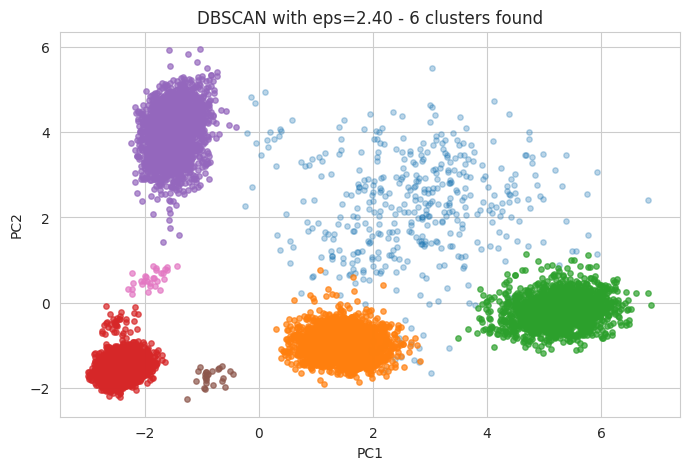

In [20]:
db = DBSCAN(eps=best_eps, min_samples=25).fit(scaled_array)
labels = db.labels_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

mask = labels != -1

if n_clusters > 1 and sum(mask) > 1:
    sil = silhouette_score(scaled_array[mask], labels[mask])
    dbi = davies_bouldin_score(scaled_array[mask], labels[mask])
    ch  = calinski_harabasz_score(scaled_array[mask], labels[mask])
else:
    sil, dbi, ch = -1, -1, -1
print(f"eps={best_eps:.2f} -> Clusters: {n_clusters}, Noise: {n_noise} ({100*n_noise/len(labels):.1f}%), Total: {len(labels)}")
print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin: {dbi:.4f}")
print(f"Calinski-Harabasz: {ch:.2f}")
print(f"Core samples: {len(db.core_sample_indices_)}")

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(scaled_array)

plt.figure(figsize=(8, 5))
for lbl in sorted(set(labels)):
    mask_lbl = labels == lbl
    color = 'black' if lbl == -1 else None
    alpha = 0.3 if lbl == -1 else 0.7

    plt.scatter(
        X_2d[mask_lbl, 0],
        X_2d[mask_lbl, 1],
        s=15,
        alpha=alpha,
        label="Noise" if lbl == -1 else f"Cluster {lbl}"
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"DBSCAN with eps={best_eps:.2f} - {n_clusters} clusters found")
plt.show()

In [21]:
unique, counts = np.unique(labels, return_counts=True)
for label, count in zip(unique, counts):
    if label == -1:
        print(f"Noise: {count}")
    else:
        print(f"Cluster {label}: {count} points")

Noise: 426
Cluster 0: 2870 points
Cluster 1: 1752 points
Cluster 2: 4601 points
Cluster 3: 2308 points
Cluster 4: 25 points
Cluster 5: 29 points


Final Evaluation and Visualization(Multiple EPS)

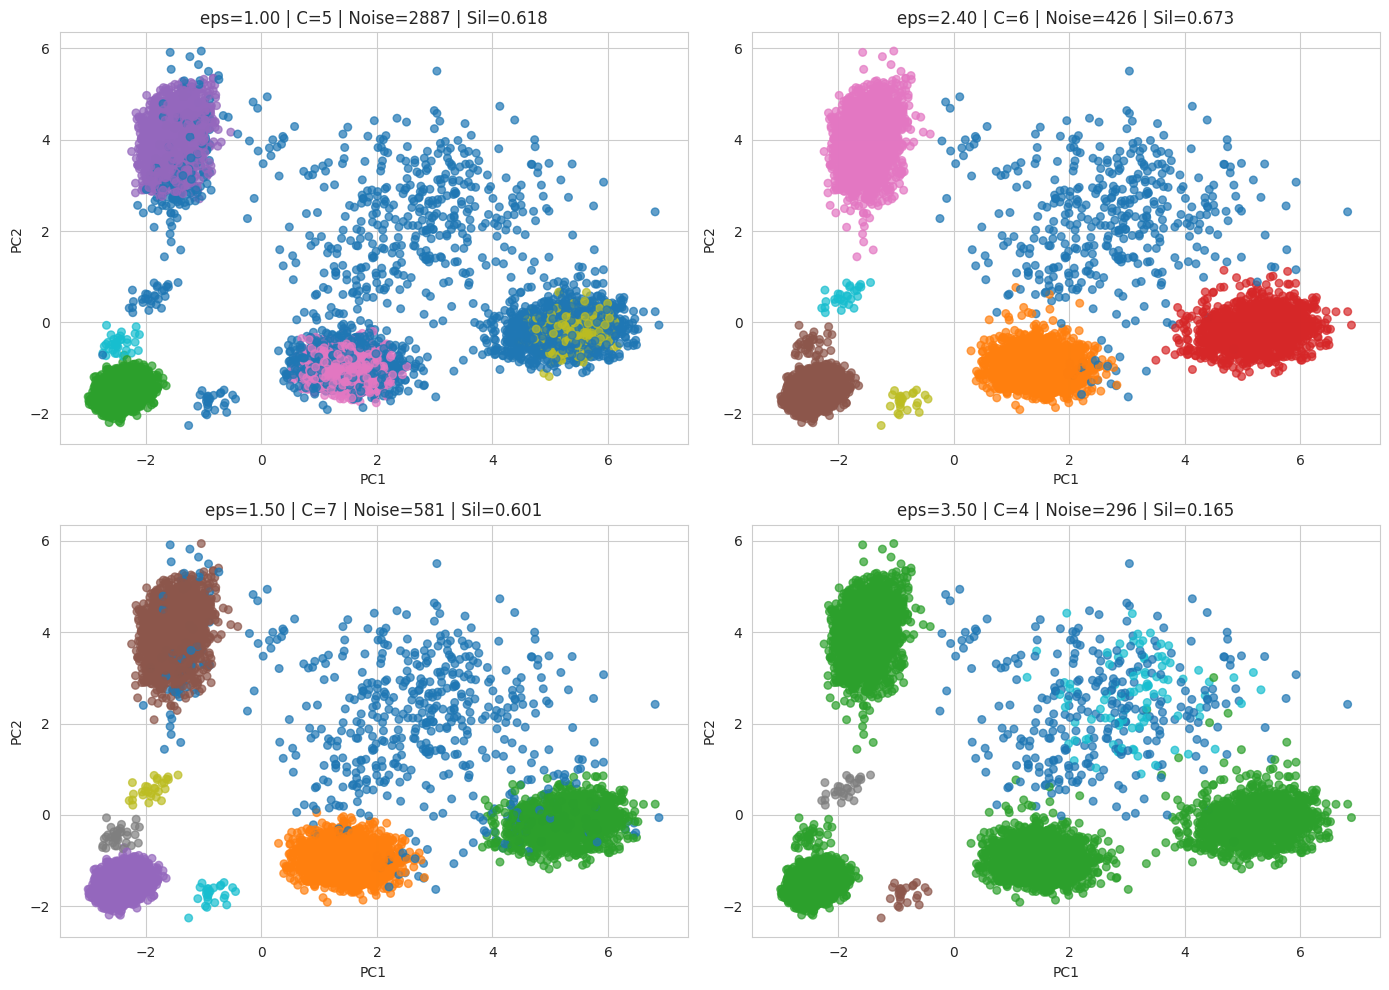

In [22]:
eps_values = [1.0, best_eps, 1.5, 3.5]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, eps in zip(axes.flatten(), eps_values):
    db = DBSCAN(eps=eps, min_samples=25).fit(scaled_array)
    labels = db.labels_

    mask = labels != -1
    score = silhouette_score(scaled_array[mask], labels[mask]) if len(set(labels[mask])) > 1 else -1

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=30, alpha=0.7)
    ax.set_title(f"eps={eps:.2f} | C={n_clusters} | Noise={n_noise} | Sil={score:.3f}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

Save Model & Data

In [24]:
import joblib

# save scaler
joblib.dump(scaler, "scaler.pkl")

# save trained DBSCAN model
joblib.dump(db, "dbscan_model.pkl")

df.to_csv("final_clustered_data.csv", index=False)

print("Model and clustered data saved successfully")

Model and clustered data saved successfully
